In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure visualization defaults
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [9]:
# Point to the adjacent data folder from the scripts folder
data_dir = Path('../data')

df_tx = pd.read_csv(data_dir / "wban_sim_tx.csv")
df_rx = pd.read_csv(data_dir / "wban_sim_lpu_rx.csv")
df_hub = pd.read_csv(data_dir / "wban_sim_hub.csv")
df_drops = pd.read_csv(data_dir / "wban_sim_drops.csv")

print(f"Loaded Tx rows: {len(df_tx)}")
print(f"Loaded Rx rows: {len(df_rx)}")
df_rx.head()

Loaded Tx rows: 1640
Loaded Rx rows: 1639


,Time_s,NodeID,SeqNum,Priority,E2EDelay_s,Size_bytes
0,2.05305,2,1,2,0.006266,90
1,2.05691,2,2,2,0.010122,90
2,2.06628,3,1,2,0.004138,90
3,2.07258,3,2,2,0.010434,90
4,2.07889,3,3,2,0.016750,90


In [10]:
# Map priority integers to human-readable QoS tags
prio_map = {0: 'CP', 1: 'RP', 2: 'DP', 3: 'OP'}
for df in [df_tx, df_rx]:
    if 'Priority' in df.columns:
        df['QoS_Tag'] = df['Priority'].map(prio_map)

# Sort Rx data chronologically per node for jitter calculation
df_rx = df_rx.sort_values(by=['NodeID', 'Time_s'])

In [11]:
total_tx = len(df_tx)
total_rx = len(df_rx)
pdr = (total_rx / total_tx) * 100 if total_tx > 0 else 0

mean_delay = df_rx['E2EDelay_s'].mean()
delay_by_prio = df_rx.groupby('QoS_Tag')['E2EDelay_s'].mean()

# Calculate jitter (absolute difference between consecutive packet delays)
df_rx['Jitter_s'] = df_rx.groupby('NodeID')['E2EDelay_s'].diff().abs()
mean_jitter = df_rx['Jitter_s'].mean()

print(f"Packet Delivery Ratio (PDR): {pdr:.2f}%")
print(f"Overall Mean End-to-End Delay: {mean_delay:.4f} seconds")
print(f"Overall Mean Jitter: {mean_jitter:.4f} seconds")
print("\nMean Delay by Priority:\n", delay_by_prio)

Packet Delivery Ratio (PDR): 99.94%
Overall Mean End-to-End Delay: 0.0081 seconds
Overall Mean Jitter: 0.0054 seconds

Mean Delay by Priority:
 QoS_Tag
CP    0.007491
DP    0.008445
OP    0.006463
RP    0.004939
Name: E2EDelay_s, dtype: float64


In [12]:
sim_duration = 100.0 # Standard simulation period

# Goodput: Useful application payload bits delivered to LPU per second
rx_bytes = df_rx['Size_bytes'].sum()
goodput_bps = (rx_bytes * 8) / sim_duration

# Throughput: Raw physical MAC layer frames arriving at the Hub
hub_mac_rx = df_hub[df_hub['Event'] == 'Rx_802.15.4']
mac_bytes = hub_mac_rx['Size_bytes'].sum()
throughput_bps = (mac_bytes * 8) / sim_duration

print(f"Application Goodput: {goodput_bps:.2f} bps")
print(f"MAC Layer Throughput: {throughput_bps:.2f} bps")

Application Goodput: 11308.24 bps
MAC Layer Throughput: 11422.64 bps


/tmp/ipykernel_30814/735841899.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_rx, x='QoS_Tag', y='E2EDelay_s', order=['CP', 'RP', 'DP', 'OP'], palette='Set2')


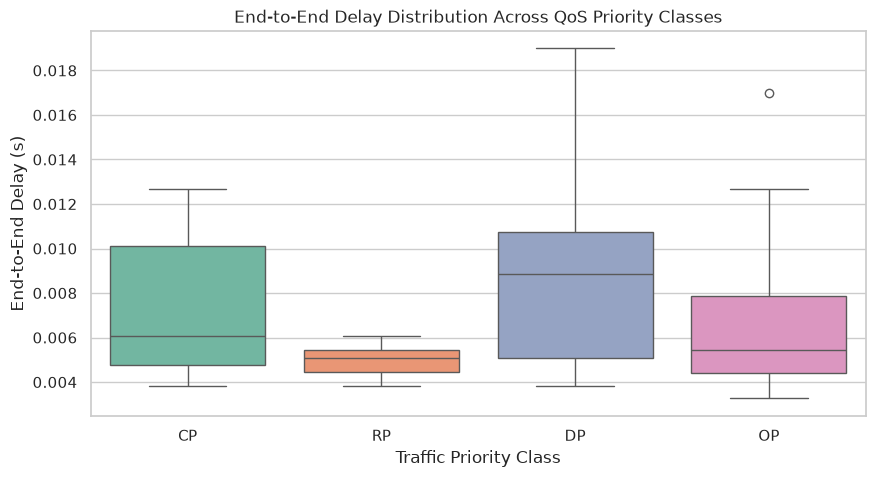

In [13]:
sns.boxplot(data=df_rx, x='QoS_Tag', y='E2EDelay_s', order=['CP', 'RP', 'DP', 'OP'], palette='Set2')
plt.title('End-to-End Delay Distribution Across QoS Priority Classes')
plt.xlabel('Traffic Priority Class')
plt.ylabel('End-to-End Delay (s)')
plt.show()

In [14]:
if not df_drops.empty:
    drop_counts = df_drops['Layer'].value_counts()
    drop_counts.plot(kind='bar', color='salmon', edgecolor='black')
    plt.title('Packet Drops Categorized by Network Layer')
    plt.xlabel('Layer')
    plt.ylabel('Drop Count')
    plt.xticks(rotation=0)
    plt.show()
else:
    print("No drops recorded in this simulation run.")

No drops recorded in this simulation run.


In [15]:
# Define node configuration metadata based on wban-config.cc
node_metadata = {
    2: {"SensorName": "EEG", "SensorType": "Streaming (P0)"},
    3: {"SensorName": "HearingAid", "SensorType": "Streaming (P0)"},
    5: {"SensorName": "ECG", "SensorType": "Streaming (P0)"},
    10: {"SensorName": "EMG", "SensorType": "Streaming (P0)"},
    6: {"SensorName": "BloodPressure", "SensorType": "High Event (P1)"},
    7: {"SensorName": "InsulinPump", "SensorType": "High Event (P1)"},
    8: {"SensorName": "SpO2", "SensorType": "High Event (P1)"},
    4: {"SensorName": "Temperature", "SensorType": "Routine (P2)"},
    9: {"SensorName": "Accelerometer", "SensorType": "Routine (P2)"},
    11: {"SensorName": "MotionSensor", "SensorType": "Routine (P2)"}
}

# 1. Calculate Sent and Received counts per NodeID
tx_node = df_tx.groupby('NodeID').size().reset_index(name='Tx_Packets')
rx_node = df_rx.groupby('NodeID').size().reset_index(name='Rx_Packets')

# 2. Merge counts to compute per-node PDR
node_perf = pd.merge(tx_node, rx_node, on='NodeID', how='outer').fillna(0)
node_perf['PDR_%'] = (node_perf['Rx_Packets'] / node_perf['Tx_Packets']) * 100

# 3. Calculate Mean End-to-End Delay per NodeID
mean_delay_node = df_rx.groupby('NodeID')['E2EDelay_s'].mean().reset_index(name='Mean_Delay_s')

# 4. Calculate Mean Jitter per NodeID (consecutive absolute delay delta)
df_rx_sorted = df_rx.sort_values(by=['NodeID', 'Time_s'])
df_rx_sorted['Jitter_s'] = df_rx_sorted.groupby('NodeID')['E2EDelay_s'].diff().abs()
mean_jitter_node = df_rx_sorted.groupby('NodeID')['Jitter_s'].mean().reset_index(name='Mean_Jitter_s')

# 5. Combine all metrics into a unified summary table
node_perf = node_perf.merge(mean_delay_node, on='NodeID', how='left').merge(mean_jitter_node, on='NodeID', how='left')
node_perf['SensorName'] = node_perf['NodeID'].map(lambda x: node_metadata.get(x, {}).get('SensorName', 'Unknown'))
node_perf['SensorType'] = node_perf['NodeID'].map(lambda x: node_metadata.get(x, {}).get('SensorType', 'Unknown'))

# Reorder columns for readability
node_perf = node_perf[['NodeID', 'SensorName', 'SensorType', 'Tx_Packets', 'Rx_Packets', 'PDR_%', 'Mean_Delay_s', 'Mean_Jitter_s']]
node_perf = node_perf.sort_values(by='NodeID').reset_index(drop=True)

print("--- PER-NODE PERFORMANCE TABLE ---")
display(node_perf)

--- PER-NODE PERFORMANCE TABLE ---


,NodeID,SensorName,SensorType,Tx_Packets,Rx_Packets,PDR_%,Mean_Delay_s,Mean_Jitter_s
0,2,EEG,Streaming (P0),386,386,100.00000,0.007627,0.005470
1,3,HearingAid,Streaming (P0),438,438,100.00000,0.010206,0.006978
2,4,Temperature,Routine (P2),1,1,100.00000,0.004167,NaN
3,5,ECG,Streaming (P0),294,294,100.00000,0.007710,0.004854
4,8,SpO2,High Event (P1),125,125,100.00000,0.004941,0.000814
5,9,Accelerometer,Routine (P2),5,5,100.00000,0.003783,0.000665
6,10,EMG,Streaming (P0),382,381,99.73822,0.007688,0.005441
7,11,MotionSensor,Routine (P2),9,9,100.00000,0.004306,0.000997


In [16]:
# Group performance metrics by SensorType
type_perf = node_perf.groupby('SensorType').agg({
    'Tx_Packets': 'sum',
    'Rx_Packets': 'sum',
    'Mean_Delay_s': 'mean',
    'Mean_Jitter_s': 'mean'
}).reset_index()

type_perf['PDR_%'] = (type_perf['Rx_Packets'] / type_perf['Tx_Packets']) * 100
type_perf = type_perf[['SensorType', 'Tx_Packets', 'Rx_Packets', 'PDR_%', 'Mean_Delay_s', 'Mean_Jitter_s']]

print("--- PERFORMANCE BY TRAFFIC HIERARCHY TYPE ---")
display(type_perf)

--- PERFORMANCE BY TRAFFIC HIERARCHY TYPE ---


,SensorType,Tx_Packets,Rx_Packets,PDR_%,Mean_Delay_s,Mean_Jitter_s
0,High Event (P1),125,125,100.000000,0.004941,0.000814
1,Routine (P2),15,15,100.000000,0.004085,0.000831
2,Streaming (P0),1500,1499,99.933333,0.008308,0.005686


/tmp/ipykernel_30814/3814222536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=node_perf, x='SensorName', y='Mean_Delay_s', ax=ax1, palette='Blues_d', alpha=0.8)


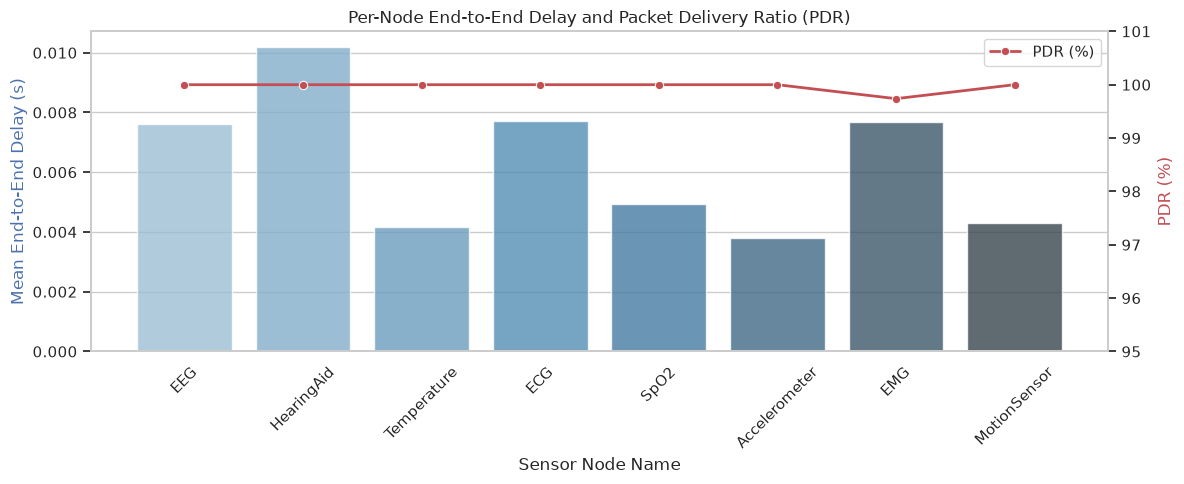

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Mean Delay per Sensor Name
sns.barplot(data=node_perf, x='SensorName', y='Mean_Delay_s', ax=ax1, palette='Blues_d', alpha=0.8)
ax1.set_title('Per-Node End-to-End Delay and Packet Delivery Ratio (PDR)')
ax1.set_xlabel('Sensor Node Name')
ax1.set_ylabel('Mean End-to-End Delay (s)', color='b')
ax1.tick_params(axis='x', rotation=45)

# Create a secondary axis for PDR percentage
ax2 = ax1.twinx()
sns.lineplot(data=node_perf, x='SensorName', y='PDR_%', ax=ax2, color='r', marker='o', linewidth=2, label='PDR (%)')
ax2.set_ylabel('PDR (%)', color='r')
ax2.set_ylim(95, 101) # PDR is high near 100%
ax2.grid(False)

plt.tight_layout()
plt.show()